In [49]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import Dict, List, Tuple
from training.data_loading import *
from training.loss_funcs import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}") # I have a 3090
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")
# ── ARIMAX-specific imports ─────────────────────────────────────
import itertools
import time
import os
from collections import defaultdict, Counter

import mlflow
from tqdm.notebook import tqdm
from tqdm import tqdm as _ttqdm   # plain text tqdm — safe with joblib generators
from joblib import Parallel, delayed
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX  # used as ARIMAX (no seasonal order)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

N_CORES = max(1, (os.cpu_count() or 4) - 1)
print(f"statsmodels ARIMAX ready, mlflow {mlflow.__version__}, n_cores={N_CORES}")

PyTorch version  : 2.10.0
CUDA available   : False
statsmodels ARIMAX ready, mlflow 3.11.1, n_cores=7


In [50]:
weather_cols_all = ['temperature_2m',
       'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
       'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance']

other_cols = [ # these are not static
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + static_cols + other_cols
print(f"y col is: {Y_COL}, group col is: {GROUP_COL}\n"
      f"features: {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
features: ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [51]:
# this data has a data column and categorical columns are kept intact and will need to be handled.
# "time_idx" is already built in train, val and test and is continuous through them
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val : (293880, 38)
test: (295430, 38)


In [52]:
# # If a model cant handle categorical columns natively, or through embedings use this data
# # It has no datetime column and all columns are numeric, as all cat column were ohe
# # GROUP_COL is the only exception, and is not ohe. Ohe it before training
# print("Loading train …")
# train = load_and_prepare(TRAIN_PATH_OHE)
#
# print("Loading val   …")
# val = load_and_prepare(VAL_PATH_OHE)
#
# print("Loading test  …")
# test = load_and_prepare(TEST_PATH_OHE)
#
# print(f"train: {train.shape}")
# print(f"val  : {val.shape}")
# print(f"test : {test.shape}")

In [53]:
# this cell samples locations, I'll use it if training takes too long, otherwise don't touch it

TARGET_STATIONS = 395

station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [54]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


In [55]:
# ────────────────────────────────────────────────────────────────
# ARIMAX configuration
#
# Pipeline:
#   1. seasonal_decompose(train_y, period=24, additive)  →  trend + seasonal + resid
#   2. fit ARIMAX(p,d,q) with exogenous regressors on the RESIDUAL
#   3. forecast residual recursively, then add back extrapolated trend
#      and tiled seasonal pattern
#   4. clip to >= 0
#
# Why this is faster than SARIMAX:
#   - no seasonal_order, no seasonal lag in the state space
#   - residual is approximately stationary, so small (p, d, q) suffice
# ────────────────────────────────────────────────────────────────

EXOG_COLS = [
    'dam_price', 'sell_bm_price', 'buy_bm_price',
    'Hour', 'day_of_week', 'Month',
]

# ── ARIMAX grid (no seasonal terms) ─────────────────────────────
P_RANGE = [0, 1, 2, 3]
D_RANGE = [0, 1]            # residual is roughly stationary, but allow d=1 just in case
Q_RANGE = [0, 1, 2, 3]

# ── Seasonal decomposition ──────────────────────────────────────
DECOMP_PERIOD = 24          # daily seasonality on hourly data
TREND_TAIL_HOURS = 24 * 14  # last 2 weeks of the trend used to fit the linear extrapolator

# ── Clustering ──────────────────────────────────────────────────
N_CLUSTERS = 15

# ── Search history subsampling ──────────────────────────────────
SEARCH_TAIL_HOURS = 24 * 90

TOP_K_BY_AIC   = 5
FORECAST_BLOCK = 48
FIT_MAXITER    = 25
USE_SIMPLE_DIFF = True

# Build ARIMAX grid (drop the all-zeros candidate — it's just exog regression)
param_grid = list(itertools.product(P_RANGE, D_RANGE, Q_RANGE))
param_grid = [g for g in param_grid if not (g[0] == 0 and g[2] == 0)]
print(f"ARIMAX grid: {len(param_grid)} candidates")
print(f"Exogenous variables ({len(EXOG_COLS)}): {EXOG_COLS}")

mlflow.set_experiment("arimax_electricity")
mlflow.start_run(run_name=f"arimax_decomp_{int(time.time())}")
mlflow.log_params({
    "model":              "ARIMAX + seasonal_decompose",
    "y_col":              Y_COL,
    "group_col":          GROUP_COL,
    "exog_cols":          ",".join(EXOG_COLS),
    "grid_size":          len(param_grid),
    "top_k_by_aic":       TOP_K_BY_AIC,
    "forecast_block":     FORECAST_BLOCK,
    "decomp_period":      DECOMP_PERIOD,
    "trend_tail_hours":   TREND_TAIL_HOURS,
    "n_clusters":         N_CLUSTERS,
    "search_tail_hours":  SEARCH_TAIL_HOURS,
    "fit_maxiter":        FIT_MAXITER,
    "simple_differencing":USE_SIMPLE_DIFF,
    "n_cores":            N_CORES,
    "n_train_rows":       len(train),
    "n_val_rows":         len(val),
    "n_test_rows":        len(test),
    "n_stations":         train[GROUP_COL].nunique(),
})
print(f"MLflow run started: {mlflow.active_run().info.run_id}")

ARIMAX grid: 30 candidates
Exogenous variables (6): ['dam_price', 'sell_bm_price', 'buy_bm_price', 'Hour', 'day_of_week', 'Month']
MLflow run started: 348606647b074ef8b65ff0addbf3c575


In [56]:
# ────────────────────────────────────────────────────────────────
# Helpers: decomposition, ARIMAX fit, recursive residual forecast,
# trend extrapolation, seasonal tiling, recomposition.
# ────────────────────────────────────────────────────────────────

def get_station_series(df: pd.DataFrame, eic: str):
    """Return (y, exog, full_group) for one station, sorted by time_idx."""
    g = df[df[GROUP_COL] == eic].sort_values("time_idx")
    y    = g[Y_COL].to_numpy(dtype=float)
    exog = g[EXOG_COLS].to_numpy(dtype=float)
    return y, exog, g


def decompose_train(y_train: np.ndarray, period: int = DECOMP_PERIOD):
    """Additive seasonal_decompose on the training series.

    Returns (trend, seasonal_pattern, resid, last_obs_idx) where:
      - trend          : 1-D array same length as y_train (NaN at the ends)
      - seasonal_pattern: length-`period` array (one full period; tile this forward)
      - resid          : y_train - trend - seasonal (NaN at the ends — we drop those)
      - last_obs_idx   : last index in y_train where trend is finite
    """
    dec = seasonal_decompose(y_train, model="additive", period=period,
                             extrapolate_trend=0, two_sided=True)
    trend    = np.asarray(dec.trend,    dtype=float)
    seasonal = np.asarray(dec.seasonal, dtype=float)
    resid    = np.asarray(dec.resid,    dtype=float)

    # The seasonal component repeats with period `period` — take one full period
    # from a stable spot in the middle (avoids the boundary NaNs in trend/resid).
    mid = len(seasonal) // 2
    # align so the first element of the pattern corresponds to index 0 of y_train
    offset = mid % period
    seasonal_pattern = seasonal[mid - offset : mid - offset + period]
    if len(seasonal_pattern) != period:
        seasonal_pattern = seasonal[:period]

    finite_trend = np.where(np.isfinite(trend))[0]
    last_obs_idx = int(finite_trend[-1]) if len(finite_trend) else len(y_train) - 1
    return trend, seasonal_pattern, resid, last_obs_idx


def extrapolate_trend(trend: np.ndarray, last_obs_idx: int,
                      horizon: int, tail: int = TREND_TAIL_HOURS) -> np.ndarray:
    """Robust trend extrapolation.

    Uses median-of-differences slope on the last `tail` finite trend values,
    then heavily damps it. Falls back to flat extrapolation on degeneracy.

    Why median-of-diffs instead of polyfit:
      - polyfit/OLS is sensitive to the boundary instability of seasonal_decompose
        (NaN-padding effects + small effective sample near the edge), and can return
        a wildly wrong slope that, projected over 720 hours, blows the forecast up.
      - median(diff) is robust to outliers and stable on noisy edges.
    """
    finite = np.where(np.isfinite(trend))[0]
    if len(finite) < 2:
        last_val = float(trend[last_obs_idx]) if np.isfinite(trend[last_obs_idx]) else 0.0
        return np.full(horizon, last_val, dtype=float)

    last_val = float(trend[last_obs_idx])
    start = max(int(finite[0]), last_obs_idx - tail + 1)
    ys = trend[start:last_obs_idx + 1]
    ys = ys[np.isfinite(ys)]
    if len(ys) < 2:
        return np.full(horizon, last_val, dtype=float)

    # Robust slope = median of consecutive differences (per-hour increment).
    slope = float(np.median(np.diff(ys)))

    # Cap the slope so a month of extrapolation can't move the level by more
    # than `max_drift` of the trend's current value. Without this cap, a
    # spurious slope estimate can produce 10^20 forecasts.
    max_drift_frac = 0.20  # at most ±20% of |last_val| over the full horizon
    cap = (max_drift_frac * abs(last_val) / max(horizon, 1)) if last_val != 0 else np.inf
    slope = float(np.clip(slope, -cap, cap))

    future_offsets = np.arange(1, horizon + 1, dtype=float)
    return last_val + slope * future_offsets


def recompose_forecast(resid_pred: np.ndarray, dec: dict, horizon: int) -> np.ndarray:
    """Add back trend + seasonal to ARIMAX residual forecasts, with a sanity clip.

    The clip is defensive: even with robust trend extrapolation, ARIMAX in residual
    space can occasionally diverge for ill-conditioned series. We bound the final
    forecast to [0, CLIP_MULT * max(historical y)] so one bad station can't poison
    aggregate metrics.
    """
    trend_future = extrapolate_trend(dec["trend"], dec["last_obs_idx"], horizon)
    period       = len(dec["seasonal_pattern"])
    start_phase  = dec["n_train"] % period
    seasonal_future = tile_seasonal(dec["seasonal_pattern"], start_phase, horizon)
    forecast = resid_pred + trend_future + seasonal_future

    # Defensive clip — bounds based on training-history magnitude.
    y_max = dec.get("y_train_max", np.nan)
    if np.isfinite(y_max) and y_max > 0:
        upper = 5.0 * y_max
        forecast = np.clip(forecast, a_min=0.0, a_max=upper)
    else:
        forecast = np.clip(forecast, a_min=0.0, a_max=None)
    return forecast


def tile_seasonal(seasonal_pattern: np.ndarray, start_phase: int,
                  horizon: int) -> np.ndarray:
    """Tile the seasonal pattern forward starting from phase `start_phase`.

    `start_phase` is the index within the pattern that corresponds to the
    first forecast hour. For us this is just (last_train_idx + 1) % period
    when the pattern was extracted with offset 0.
    """
    period = len(seasonal_pattern)
    idx = (np.arange(horizon) + start_phase) % period
    return seasonal_pattern[idx]


def fit_arimax(y, exog, order,
               maxiter: int = FIT_MAXITER,
               simple_diff: bool = USE_SIMPLE_DIFF):
    """Fit an ARIMAX (SARIMAX with no seasonal order). Returns result or None."""
    try:
        model = SARIMAX(
            endog=y,
            exog=exog,
            order=order,
            seasonal_order=(0, 0, 0, 0),   # no seasonal — that's been removed
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=simple_diff,
        )
        return model.fit(disp=False, maxiter=maxiter, method="lbfgs")
    except Exception:
        return None


def recursive_forecast(fit_result, exog_future: np.ndarray,
                       block: int = FORECAST_BLOCK) -> np.ndarray:
    """Forecast residuals `len(exog_future)` steps ahead in blocks.

    State is extended with the model's own predictions (no future-target leakage).
    """
    horizon = len(exog_future)
    preds   = np.empty(horizon, dtype=float)
    state   = fit_result
    cursor  = 0
    while cursor < horizon:
        step = min(block, horizon - cursor)
        exog_slice = exog_future[cursor:cursor + step]
        fc = state.get_forecast(steps=step, exog=exog_slice)
        block_pred = np.asarray(fc.predicted_mean, dtype=float)
        preds[cursor:cursor + step] = block_pred
        cursor += step
        if cursor < horizon:
            state = state.append(endog=block_pred, exog=exog_slice, refit=False)
    return preds


def _prices_arr(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values


def prepare_station_for_arimax(y_train: np.ndarray, exog_train: np.ndarray):
    """Run decomposition on training series, return everything needed downstream."""
    trend, seasonal_pattern, resid, last_obs_idx = decompose_train(y_train, DECOMP_PERIOD)
    mask = np.isfinite(resid) & np.isfinite(trend)
    return {
        "resid_train":      resid[mask],
        "exog_train_clean": exog_train[mask],
        "trend":            trend,
        "seasonal_pattern": seasonal_pattern,
        "last_obs_idx":     last_obs_idx,
        "n_train":          len(y_train),
        "y_train_max":      float(np.nanmax(y_train)) if len(y_train) else np.nan,
    }


print("ARIMAX helpers ready.")

ARIMAX helpers ready.


In [57]:
# ────────────────────────────────────────────────────────────────
# Cluster stations by load shape, optimise ONE representative per cluster.
# 31-dim profile = 24 hour-of-day + 7 day-of-week (both shape-normalised).
# ────────────────────────────────────────────────────────────────

stations_all = sorted(train[GROUP_COL].unique().tolist())
print(f"Total stations: {len(stations_all)}")

def station_profile(df: pd.DataFrame) -> np.ndarray:
    by_hour = df.groupby("Hour")[Y_COL].mean().reindex(range(24), fill_value=0).values
    by_dow  = df.groupby("day_of_week")[Y_COL].mean().reindex(range(7),  fill_value=0).values
    h_mean = by_hour.mean() if by_hour.mean() > 0 else 1.0
    d_mean = by_dow.mean()  if by_dow.mean()  > 0 else 1.0
    return np.concatenate([by_hour / h_mean, by_dow / d_mean])

profiles = []
for eic in tqdm(stations_all, desc="Profiling stations"):
    g = train[train[GROUP_COL] == eic]
    profiles.append(station_profile(g))
profiles = np.vstack(profiles)

scaler    = StandardScaler()
profilesZ = scaler.fit_transform(profiles)

n_clusters = min(N_CLUSTERS, len(stations_all))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_id = kmeans.fit_predict(profilesZ)

station_to_cluster = dict(zip(stations_all, cluster_id))

cluster_to_rep: Dict[int, str] = {}
for c in range(n_clusters):
    members = np.where(cluster_id == c)[0]
    if len(members) == 0:
        continue
    centroid = kmeans.cluster_centers_[c]
    dists = np.linalg.norm(profilesZ[members] - centroid, axis=1)
    rep_idx = members[int(np.argmin(dists))]
    cluster_to_rep[c] = stations_all[rep_idx]

cluster_sizes = Counter(cluster_id.tolist())
print("\nCluster sizes (cluster_id: n_stations):")
for c, n in sorted(cluster_sizes.items()):
    print(f"  cluster {c:2d}: {n:4d} stations  →  rep: {cluster_to_rep[c]}")

cluster_df = pd.DataFrame({GROUP_COL: stations_all, "cluster": cluster_id})
cluster_df.to_csv("arimax_clusters.csv", index=False)
mlflow.log_artifact("arimax_clusters.csv")
mlflow.log_metric("n_actual_clusters", len(cluster_to_rep))

Total stations: 395


Profiling stations:   0%|          | 0/395 [00:00<?, ?it/s]


Cluster sizes (cluster_id: n_stations):
  cluster  0:   91 stations  →  rep: 62Z4106130995736
  cluster  1:    9 stations  →  rep: 62Z661769289704V
  cluster  2:   38 stations  →  rep: 62Z6605113197287
  cluster  3:   28 stations  →  rep: 62Z7497150291839
  cluster  4:   10 stations  →  rep: 62Z0096677872985
  cluster  5:    1 stations  →  rep: 62Z0101426517156
  cluster  6:   23 stations  →  rep: 62Z1796820029369
  cluster  7:   37 stations  →  rep: 62Z5520446881915
  cluster  8:   10 stations  →  rep: 62Z5064314448909
  cluster  9:    1 stations  →  rep: 62Z2948906740151
  cluster 10:    3 stations  →  rep: 62Z4534322132001
  cluster 11:   57 stations  →  rep: 62Z6571743089872
  cluster 12:    2 stations  →  rep: 62Z4022724546559
  cluster 13:   18 stations  →  rep: 62Z4515858754299
  cluster 14:   67 stations  →  rep: 62Z0760150283041


In [58]:
# ────────────────────────────────────────────────────────────────
# Training: per-CLUSTER ARIMAX grid search on decomposition residuals
#
# For each cluster representative:
#   1. seasonal_decompose train  →  trend + seasonal + resid
#   2. fit ARIMAX(p,d,q) on the residual with exog (last SEARCH_TAIL_HOURS)
#   3. AIC pre-filter → top-K
#   4. forecast residual on val, recompose with extrapolated trend +
#      tiled seasonal, score with money_pct
#   5. propagate best order to all stations in the cluster
# ────────────────────────────────────────────────────────────────

def evaluate_candidate_for_rep(eic: str, order):
    """Worker: fit one ARIMAX candidate, return result dict or None."""
    y_tr,  exog_tr,  _      = get_station_series(train, eic)
    y_val, exog_val, val_g  = get_station_series(val,   eic)
    if len(y_tr) < 4 * DECOMP_PERIOD or len(y_val) == 0:
        return None

    # Subsample training history for the search
    if len(y_tr) > SEARCH_TAIL_HOURS:
        y_tr    = y_tr[-SEARCH_TAIL_HOURS:]
        exog_tr = exog_tr[-SEARCH_TAIL_HOURS:]

    dec = prepare_station_for_arimax(y_tr, exog_tr)
    if len(dec["resid_train"]) < 2 * DECOMP_PERIOD:
        return None

    res = fit_arimax(dec["resid_train"], dec["exog_train_clean"], order)
    if res is None or not np.isfinite(res.aic):
        return None

    try:
        resid_pred = recursive_forecast(res, exog_val)
        val_pred = recompose_forecast(resid_pred, dec, horizon=len(exog_val))
        val_pred = np.clip(val_pred, a_min=0.0, a_max=None)
    except Exception:
        return None
    if not np.all(np.isfinite(val_pred)):
        return None

    val_prices = _prices_arr(val_g)
    score = money_pct(y_val, val_pred, *val_prices)
    return {
        "aic":           float(res.aic),
        "val_money_pct": float(score),
        "order":         order,
    }


best_orders: Dict[str, Dict] = {}
cluster_best_order: Dict[int, Dict] = {}

t0 = time.time()
for c, rep_eic in tqdm(cluster_to_rep.items(), desc="Cluster reps"):
    n = len(param_grid)
    results = []
    gen = Parallel(n_jobs=N_CORES, backend="loky", verbose=0,
                   return_as="generator")(
        delayed(evaluate_candidate_for_rep)(rep_eic, (p, d, q))
        for (p, d, q) in param_grid
    )
    # plain text tqdm — safe with joblib generators (no ipywidgets in workers)
    for r in _ttqdm(gen, total=n, desc=f"  cluster {c}", leave=False):
        if r is not None:
            results.append(r)

    if not results:
        print(f"  cluster {c} ({rep_eic}): all candidates failed")
        continue

    results.sort(key=lambda r: r["aic"])
    survivors = results[:TOP_K_BY_AIC]
    best = min(survivors, key=lambda r: r["val_money_pct"])
    cluster_best_order[c] = best
    print(f"  cluster {c:2d}: order={best['order']} "
          f"money_pct={best['val_money_pct']:.3f}  aic={best['aic']:.0f}")

search_elapsed = time.time() - t0
print(f"\nGrid search done in {search_elapsed/60:.1f} min for {len(cluster_best_order)} clusters")
mlflow.log_metric("search_time_min", search_elapsed / 60)

# Propagate cluster orders to every station in that cluster
for eic in stations_all:
    c = station_to_cluster[eic]
    cfg = cluster_best_order.get(c)
    if cfg is None:
        continue
    best_orders[eic] = {
        "order":         cfg["order"],
        "val_money_pct": cfg["val_money_pct"],
        "aic":           cfg["aic"],
        "cluster":       c,
    }

# Fallback for stations whose cluster failed
if cluster_best_order:
    order_counts = Counter(b["order"] for b in cluster_best_order.values())
    fb_order = order_counts.most_common(1)[0][0]
    print(f"Fallback order: {fb_order}")
    for eic in stations_all:
        if eic not in best_orders:
            best_orders[eic] = {
                "order":         fb_order,
                "val_money_pct": float("nan"),
                "aic":           float("nan"),
                "cluster":       station_to_cluster[eic],
                "fallback":      True,
            }

orders_df = pd.DataFrame([
    {GROUP_COL:       k,
     "cluster":       v["cluster"],
     "order":         str(v["order"]),
     "val_money_pct": v["val_money_pct"],
     "aic":           v["aic"],
     "fallback":      v.get("fallback", False)}
    for k, v in best_orders.items()
])
orders_df.to_csv("arimax_best_orders.csv", index=False)
mlflow.log_artifact("arimax_best_orders.csv")
mlflow.log_metric("n_optimised_stations",
                  sum(1 for v in best_orders.values() if not v.get("fallback")))
print(orders_df.head())

Cluster reps:   0%|          | 0/15 [00:00<?, ?it/s]


  cluster 0:   0%|          | 0/30 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 0:   3%|▎         | 1/30 [00:06<03:08,  6.52s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 0:  10%|█         | 3/30 [00:07<00:54,  2.01s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-pac

  cluster  0: order=(2, 0, 0) money_pct=9.424  aic=-4614



  cluster 1:   0%|          | 0/30 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 1:   3%|▎         | 1/30 [00:02<01:08,  2.35s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 1:  13%|█▎        | 4/30 [00:04<00:24,  1.08it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-pac

  cluster  1: order=(3, 0, 1) money_pct=20.542  aic=2202


...

  cluster 12: order=(3, 0, 1) money_pct=9.027  aic=11610



  cluster 13:   0%|          | 0/30 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 13:   3%|▎         | 1/30 [00:02<01:10,  2.44s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 13:  10%|█         | 3/30 [00:03<00:30,  1.13s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-

  cluster 13: order=(3, 0, 3) money_pct=3.738  aic=976



  cluster 14:   0%|          | 0/30 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 14:   7%|▋         | 2/30 [00:02<00:31,  1.14s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 14:  10%|█         | 3/30 [00:03<00:30,  1.14s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 14:  17%|█▋        | 5/30 [00:04<00:17,  1.46it/s]/U

  cluster 14: order=(2, 0, 1) money_pct=2.931  aic=1803

Grid search done in 6.0 min for 15 clusters
Fallback order: (2, 0, 1)
           eic_code  cluster      order  val_money_pct           aic  fallback
0  62Z0008583037334        4  (2, 0, 1)       3.441052   2679.528727     False
1  62Z0011230718431        4  (2, 0, 1)       3.441052   2679.528727     False
2  62Z0096677872985        4  (2, 0, 1)       3.441052   2679.528727     False
3  62Z0101426517156        5  (2, 0, 2)      29.015712  21689.419015     False
4  62Z013852333354Y        4  (2, 0, 1)       3.441052   2679.528727     False


In [59]:
# ────────────────────────────────────────────────────────────────
# Inference: produce val_eval and test_eval
#
# For each station (parallel across cores), using its cluster's chosen order:
#   - val_eval : decompose TRAIN, fit ARIMAX on residual, forecast → recompose
#                with trend (extrapolated from train trend) + seasonal pattern
#   - test_eval: decompose TRAIN+VAL, fit ARIMAX on residual, forecast → recompose
#
# We use the FULL training history here; the search ran on the tail for speed,
# but final fits should see everything.
# ────────────────────────────────────────────────────────────────

def forecast_one_station(eic: str):
    """Worker: produce (val_chunk, test_chunk) for one station."""
    cfg = best_orders.get(eic)
    if cfg is None:
        return None, None
    order = cfg["order"]

    y_tr,  exog_tr,  _      = get_station_series(train, eic)
    y_val, exog_val, val_g  = get_station_series(val,   eic)
    y_te,  exog_te,  test_g = get_station_series(test,  eic)

    val_chunk  = None
    test_chunk = None

    # ── Validation: decompose TRAIN, ARIMAX on residual, forecast val ──
    if len(y_val) > 0 and len(y_tr) >= 4 * DECOMP_PERIOD:
        try:
            dec_tr = prepare_station_for_arimax(y_tr, exog_tr)
            res_tr = fit_arimax(dec_tr["resid_train"], dec_tr["exog_train_clean"], order)
            if res_tr is not None:
                resid_pred = recursive_forecast(res_tr, exog_val)
                val_pred   = recompose_forecast(resid_pred, dec_tr, horizon=len(exog_val))
                v = val_g[[GROUP_COL, "datetime", "time_idx", Y_COL,
                           "dam_price", "sell_bm_price", "buy_bm_price"]].copy()
                v["pred"] = np.clip(val_pred, a_min=0.0, a_max=None)
                val_chunk = v
        except Exception:
            pass

    # ── Test: decompose TRAIN+VAL, ARIMAX on residual, forecast test ──
    if len(y_te) == 0:
        return val_chunk, None

    y_full    = np.concatenate([y_tr, y_val]) if len(y_val) else y_tr
    exog_full = np.vstack([exog_tr, exog_val]) if len(exog_val) else exog_tr
    if len(y_full) < 4 * DECOMP_PERIOD:
        return val_chunk, None

    try:
        dec_full = prepare_station_for_arimax(y_full, exog_full)
        res_full = fit_arimax(dec_full["resid_train"], dec_full["exog_train_clean"], order)
        if res_full is None:
            return val_chunk, None
        resid_pred = recursive_forecast(res_full, exog_te)
        test_pred  = recompose_forecast(resid_pred, dec_full, horizon=len(exog_te))
        t = test_g[[GROUP_COL, "datetime", "time_idx", Y_COL,
                    "dam_price", "sell_bm_price", "buy_bm_price"]].copy()
        t["pred"] = np.clip(test_pred, a_min=0.0, a_max=None)
        test_chunk = t
    except Exception:
        pass
    return val_chunk, test_chunk


t0 = time.time()
n = len(stations_all)
gen = Parallel(n_jobs=N_CORES, backend="loky", verbose=0,
               return_as="generator")(
    delayed(forecast_one_station)(eic) for eic in stations_all
)
results = list(_ttqdm(gen, total=n, desc="Forecasting (parallel)"))
infer_elapsed = time.time() - t0
print(f"Inference done in {infer_elapsed/60:.1f} min")
mlflow.log_metric("infer_time_min", infer_elapsed / 60)

val_chunks  = [v for v, _ in results if v is not None]
test_chunks = [t for _, t in results if t is not None]

val_eval  = pd.concat(val_chunks,  ignore_index=True) if val_chunks  else pd.DataFrame()
test_eval = pd.concat(test_chunks, ignore_index=True) if test_chunks else pd.DataFrame()

if not val_eval.empty:
    val_bias  = float(val_eval["pred"].sum()  - val_eval[Y_COL].sum())
    mlflow.log_metric("val_pred_bias",  val_bias)
if not test_eval.empty:
    test_bias = float(test_eval["pred"].sum() - test_eval[Y_COL].sum())
    mlflow.log_metric("test_pred_bias", test_bias)

if not test_eval.empty:
    ex_eic = test_eval[GROUP_COL].iloc[0]
    ex = test_eval[test_eval[GROUP_COL] == ex_eic].head(168)
    ex.to_csv("arimax_example_predictions.csv", index=False)
    mlflow.log_artifact("arimax_example_predictions.csv")

print(f"val_eval : {val_eval.shape}")
print(f"test_eval: {test_eval.shape}")

Forecasting (parallel):   0%|          | 0/395 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. 

Inference done in 20.1 min
val_eval : (293880, 8)
test_eval: (295430, 8)


In [60]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 24.3903
RMSE      : 17.4946
MAPE      : 31.35 %
MONEY     : 3055432.4141
MONEY_PCT : 10.4515%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 21.8916
RMSE      : 17.4358
MAPE      : 34.60 %
MONEY     : 3478011.1521
MONEY_PCT : 11.7692%
MLflow run logged → file:///Users/levkupybida/PycharmProjects/Diploma/train_models_v2/mlruns


In [61]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:    grp,
            "n":          len(gdf),
            "SMAPE":      smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":       rmse (gdf[Y_COL], gdf["pred"]),
            "MAE":        float(np.mean(np.abs(gdf[Y_COL].values - gdf["pred"].values))),
            "MAPE":       mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":      money     (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT":  money_pct (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "BIAS":       float(gdf["pred"].sum() - gdf[Y_COL].sum()),
        })
    return pd.DataFrame(rows).sort_values("MONEY_PCT")


test_station_metrics = per_station_metrics(test_eval)
val_station_metrics  = per_station_metrics(val_eval)

agg = {
    "agg_test_smape_mean":     float(test_station_metrics["SMAPE"].mean()),
    "agg_test_rmse_mean":      float(test_station_metrics["RMSE"].mean()),
    "agg_test_mae_mean":       float(test_station_metrics["MAE"].mean()),
    "agg_test_mape_mean":      float(test_station_metrics["MAPE"].mean()),
    "agg_test_money_pct_mean": float(test_station_metrics["MONEY_PCT"].mean()),
    "agg_test_money_sum":      float(test_station_metrics["MONEY"].sum()),
}
mlflow.log_metrics(agg)
test_station_metrics.to_csv("arimax_test_per_station.csv", index=False)
mlflow.log_artifact("arimax_test_per_station.csv")

print("Top-10 best stations (test MONEY_PCT):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test MONEY_PCT):")
print(test_station_metrics.tail(10).to_string(index=False))

Top-10 best stations (test MONEY_PCT):
        eic_code   n    SMAPE     RMSE      MAE     MAPE       MONEY  MONEY_PCT         BIAS
62Z6969613150684 748 2.714027 1.292978 1.028140 2.710488 1966.669786   1.312716    -8.920573
62Z9572466865833 748 4.285106 3.482141 2.793924 4.153200 3776.702778   1.389109 -1650.737166
62Z2655661084314 748 5.105682 0.974386 0.651852 4.930696  749.113598   1.563663  -310.304352
62Z3982836134374 748 5.131788 1.383765 0.922320 4.956927 1092.752232   1.616540  -426.502628
62Z8267336736253 748 4.786767 0.936069 0.683800 4.723173  946.455235   1.675985  -143.508051
62Z9767507424207 748 6.425964 0.786483 0.615344 6.185177  692.389458   1.687090  -262.564105
62Z897401965339V 748 4.528145 1.133614 0.835803 4.467219 1194.000578   1.689747  -240.817210
62Z9179474926730 748 4.821498 1.073380 0.716586 4.715084  960.216342   1.709303  -195.878265
62Z7932254060039 748 4.889629 1.053514 0.799214 4.806686 1111.590352   1.737750  -292.040109
62Z277440221246K 748 5.566186 1

In [62]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):

    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

Best  station (MONEY_PCT): 62Z6969613150684


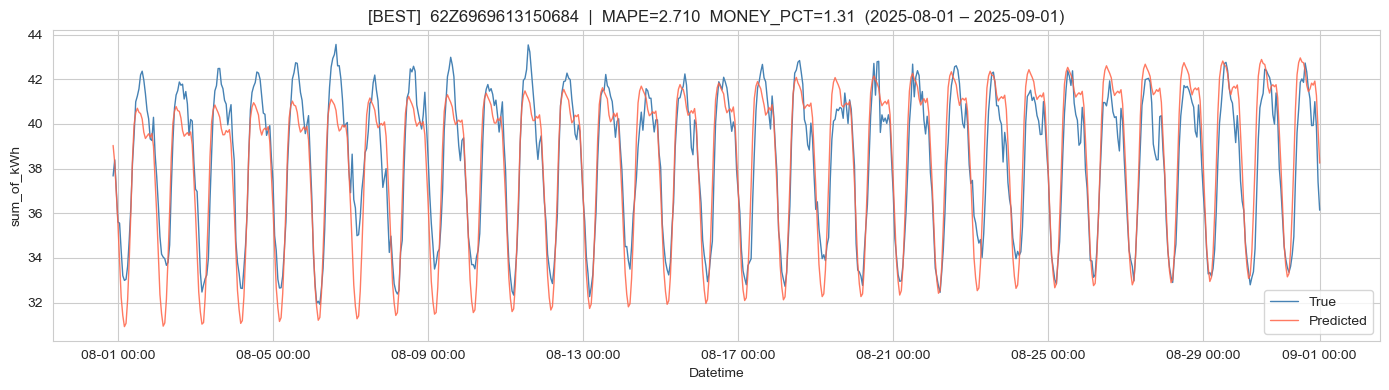

Worst station (MONEY_PCT): 62Z6624735969589


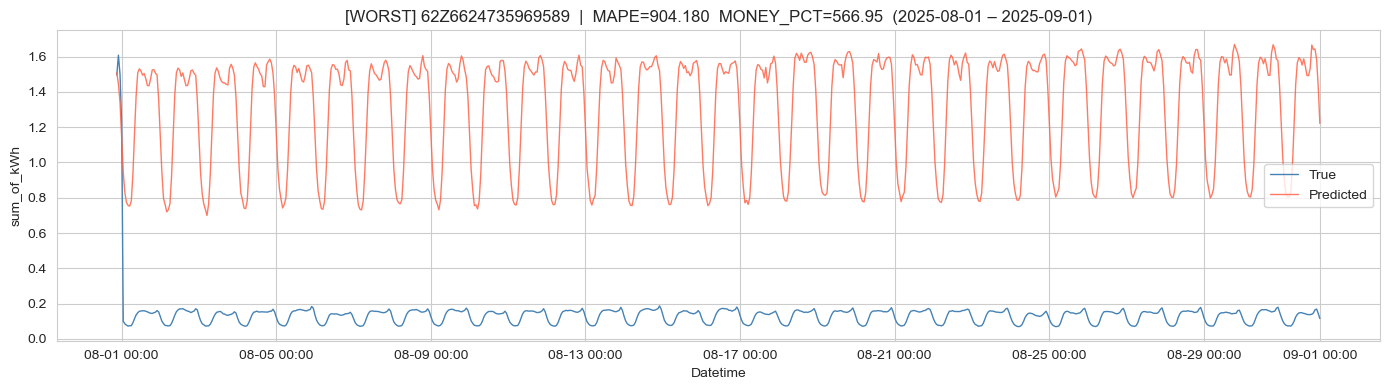

In [64]:
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-2][GROUP_COL]

print(f"Best  station (MONEY_PCT): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (MONEY_PCT): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")

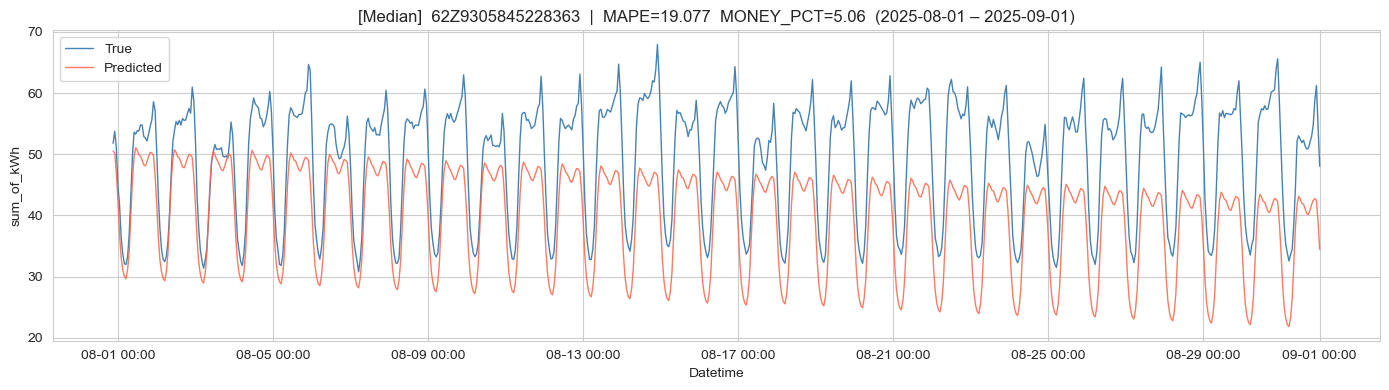

In [67]:
median  = test_station_metrics.iloc[198][GROUP_COL]

plot_forecast(test_eval, eic_code=median,  title_prefix="[Median]  ")

In [66]:
395/2

197.5